# Bab el-Mandeb (BeM) Crossing Tracker

Programmatic view of Red Sea entries/exits via Bab el-Mandeb from Kpler-style crossing history,
enriched with AFRA vessel-class mapping, OFAC sanction flags, and **Saudi-related exposure** tags.

**Context.** Recent reporting indicates cargos linked to Saudi Arabia (loaded at Saudi ports, and/or
Saudi-flag / Saudi-owned vessels) have been targeted. This file has **no beneficial-owner field**,
so ownership is out of scope; we proxy with flag + cargo origin + destination and always show *why*
a row was tagged.

**Questions this notebook answers**
1. Has overall BeM / Red Sea tanker flow been disrupted?
2. Is any change concentrated in Saudi-related traffic vs the rest of the fleet?
3. Which Saudi exposure layer drives the signal (flag / last cargo / next port)?
4. How do cargo mix, AFRA class, and dark (OFAC) vs clean fleet look around the event window?
5. Which vessels crossed most often, and who looks still inside the Red Sea?
6. What happened in the most recent day (or Fri→latest if that day is Monday)?

**Saudi-related (working definition)**
- Combined (`saudi_related`): Saudi flag **OR** last cargo country = Saudi Arabia **OR** next port country = Saudi Arabia.
- Layer flags kept separately so charts/tables can show *what* matched (`saudi_layers` / `saudi_reason`).
- Owner targeting is noted in narrative only — not in the data.

**Cargo inference**
Not every laden row has a cargo tag. We keep those rows and, when AFRA class is VLCC/ULCC,
infer `likely_crude`; otherwise leave as `unknown`.


## 1. Setup & config

Edit `EVENT_DATE` for the pre/post breakpoint. Optionally tighten `START_DATE` / `END_DATE` for the chart window.

In [27]:
from pathlib import Path
from datetime import date, timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# Muted, high-contrast palette (match SoH notebook style).
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

BASE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing")

CROSSING_PATH = BASE / "bem_crossing_hist.xlsx"
AFRA_PATH = BASE / "afra_scale_mapping.xlsx"
OFAC_IRAN_PATH = BASE / "ofac_iran_vessels_history.csv"
OFAC_SDN_PATH = BASE / "ofac_sdn_vessels_2026-07-13.csv"

# --- Period / event filters (edit these) ---
# Working default for Saudi-targeting risk window; change when you have a precise date.
EVENT_DATE = date(2026, 7, 1)

# Charts / tables default to full file history unless you tighten these.
START_DATE = date(2026, 1, 1)
END_DATE = None  # None = use max date in file

# "Likely still in Red Sea" evaluated as of this date (defaults to max crossing date)
AS_OF = None

# Recent desk pulse: None = file latest crossing day.
# Window = that day only; if that day is Monday, Friday -> latest day.
RECENT_AS_OF = None

# Pre/post comparison: lookback / lookahead days around EVENT_DATE (clipped to data).
PRE_DAYS = 28
POST_DAYS = 28

MIN_CROSSINGS = 2


## 2. Load & clean

In [28]:
def parse_dmy(series: pd.Series) -> pd.Series:
    """Crossing dates arrive as DD/MM/YYYY strings; dayfirst avoids US ambiguity."""
    return pd.to_datetime(series, dayfirst=True, errors="coerce")


def to_number(series: pd.Series) -> pd.Series:
    """Quantities/DWT often have thousand separators."""
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )


raw = pd.read_excel(CROSSING_PATH, sheet_name="BeM Crossing")
afra = pd.read_excel(AFRA_PATH)
ofac_iran = pd.read_csv(OFAC_IRAN_PATH)
ofac_sdn = pd.read_csv(OFAC_SDN_PATH)

crossings = raw.copy()
crossings["Crossing Date"] = parse_dmy(crossings["Crossing Date"])
crossings["IMO"] = pd.to_numeric(crossings["IMO"], errors="coerce").astype("Int64")
crossings["Quantity"] = to_number(crossings["Quantity"]).fillna(0.0)
crossings["Deadweight"] = to_number(crossings["Deadweight"])
# AFRA table is in thousand DWT (kdwt); convert once for joining.
crossings["dwt_kdwt"] = crossings["Deadweight"] / 1000.0

# Canonical direction labels for plotting
DIR_EXIT = "Exited Red Sea"
DIR_ENTER = "Entered Red Sea"

print(f"Rows: {len(crossings):,}")
print(
    f"Date range: {crossings['Crossing Date'].min().date()} → {crossings['Crossing Date'].max().date()}"
)
print(f"Unique IMOs: {crossings['IMO'].nunique():,}")
print("Directions:")
print(crossings["Direction"].value_counts(dropna=False))
crossings.head(3)


Rows: 561
Date range: 2026-01-01 → 2026-08-02
Unique IMOs: 398
Directions:
Direction
Exited Red Sea     524
Entered Red Sea     37
Name: count, dtype: int64


,Vessel Name,IMO,Vessel Classification,Flag Name,Direction,Crossing Date,Crossing Type,Loading State,Cargo Type,Quantity,Quantity Unit,Last Cargo Zone,Last Cargo Country,Next Port,Next Port Country,Deadweight,Build Year,Build Country,dwt_kdwt
0,LESVOS,9772321,Suezmax/LR3,MALTA,Exited Red Sea,2026-08-02,AIS Off,Laden,Crude/Co,1017760,bbl,Yanbu,Saudi Arabia,NaN,NaN,156949,"2,017",CHINA,156.949
1,DESH VAIBHAV,9297498,VLCC,INDIA,Exited Red Sea,2026-08-01,AIS Off,Laden,Crude/Co,2111483,bbl,Yanbu,Saudi Arabia,Sikka,India,316409,"2,005",REPUBLIC OF KOREA,316.409
2,MAPLE CASTOR,1069663,Intermediate Tankers,LIBERIA,Exited Red Sea,2026-07-31,AIS On,Laden,CPP,189638,bbl,Yanbu,Saudi Arabia,China,China,25996,"2,026",NaN,25.996


## 3. AFRA class + cargo inference + OFAC flags

In [29]:
def map_afra_class(dwt_kdwt: float, afra_table: pd.DataFrame) -> str | None:
    """Map kdwt into AFRA bands. Upper bound inclusive; last band catches overflow."""
    if pd.isna(dwt_kdwt):
        return None
    for _, row in afra_table.sort_values("capacity_lower_bound").iterrows():
        lo, hi = row["capacity_lower_bound"], row["capacity_upper_bound"]
        if lo <= dwt_kdwt <= hi:
            return row["vessel_class"]
    if dwt_kdwt < afra_table["capacity_lower_bound"].min():
        return "Below GP"
    return "Above ULCC"


PRODUCT_TAGS = {
    "CPP",
    "DPP",
    "Chemicals",
    "Methanol",
    "Chemicals, Methanol",
    "Veg/Bio",
    "Chemicals, Veg/Bio",
    "CPP, DPP",
    "CPP, Crude/Co",
}
CRUDE_TAGS = {"Crude/Co"}
CRUDE_LIKE_CLASSES = {"VLCC", "ULCC", "Above ULCC"}


def infer_cargo(row: pd.Series) -> tuple[str, str]:
    """Returns (cargo_group, cargo_source). Infer crude only for VLCC/ULCC-class hulls."""
    loading = row["Loading State"]
    tag = row["Cargo Type"]
    vclass = row["afra_class"]

    if loading == "Ballast":
        return "ballast", "loading_state"

    if pd.notna(tag):
        if tag in CRUDE_TAGS:
            return "crude", "tagged"
        if tag in PRODUCT_TAGS:
            return "products", "tagged"
        return "other", "tagged"

    if vclass in CRUDE_LIKE_CLASSES:
        return "likely_crude", "inferred_afra"
    return "unknown", "untagged"


crossings["afra_class"] = crossings["dwt_kdwt"].map(lambda x: map_afra_class(x, afra))

cargo_info = crossings.apply(infer_cargo, axis=1, result_type="expand")
cargo_info.columns = ["cargo_group", "cargo_source"]
crossings = pd.concat([crossings, cargo_info], axis=1)

VOLUME_GROUPS = {"crude", "likely_crude", "products"}
crossings["volume_bbl"] = np.where(
    crossings["cargo_group"].isin(VOLUME_GROUPS),
    crossings["Quantity"],
    0.0,
)


In [30]:
def normalize_imo(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")


# Dark fleet = sanctioned hulls. Iran-program list is the core signal; SDN catches extras.
iran_imos = set(normalize_imo(ofac_iran["imo"]).dropna().astype(int))
sdn_imos = set(normalize_imo(ofac_sdn["imo"]).dropna().astype(int))

crossings["sanctioned_iran"] = crossings["IMO"].isin(iran_imos)
crossings["sanctioned_sdn"] = crossings["IMO"].isin(sdn_imos)
crossings["sanctioned_any"] = crossings["sanctioned_iran"] | crossings["sanctioned_sdn"]
crossings["is_dark_fleet"] = crossings["sanctioned_any"]
crossings["fleet"] = np.where(crossings["is_dark_fleet"], "dark fleet", "clean fleet")

print("Sanction / dark-fleet overlap with crossings")
print(f"  Iran-list IMOs in file: {crossings.loc[crossings['sanctioned_iran'], 'IMO'].nunique()}")
print(f"  Any-SDN IMOs in file:   {crossings.loc[crossings['sanctioned_sdn'], 'IMO'].nunique()}")
print(f"  Dark-fleet IMOs (any OFAC): {crossings.loc[crossings['is_dark_fleet'], 'IMO'].nunique()}")
print()
print("Cargo group mix:")
print(crossings["cargo_group"].value_counts(dropna=False))
print()
print("Fleet mix (events):")
print(crossings["fleet"].value_counts())
print()
print("AFRA class mix:")
print(crossings["afra_class"].value_counts(dropna=False))


Sanction / dark-fleet overlap with crossings
  Iran-list IMOs in file: 0
  Any-SDN IMOs in file:   0
  Dark-fleet IMOs (any OFAC): 0

Cargo group mix:
cargo_group
products    282
crude       254
ballast      23
unknown       2
Name: count, dtype: int64

Fleet mix (events):
fleet
clean fleet    561
Name: count, dtype: int64

AFRA class mix:
afra_class
LR1         175
VLCC        173
AFRA         70
GP           58
MR           30
LR2          29
ULCC         23
Below GP      3
Name: count, dtype: int64


## 4. Saudi-related exposure tags

Combined bucket for disruption tests; layer flags + `saudi_reason` so every tagged row shows *why*.

In [31]:
SAUDI_COUNTRY = "Saudi Arabia"
SAUDI_FLAG = "SAUDI ARABIA"

# fillna(False): null countries/flags must not become pd.NA booleans (breaks if-checks).
crossings["saudi_flag"] = (
    crossings["Flag Name"].astype("string").str.upper().eq(SAUDI_FLAG).fillna(False)
)
crossings["saudi_load"] = (
    crossings["Last Cargo Country"].astype("string").eq(SAUDI_COUNTRY).fillna(False)
)
crossings["saudi_dest"] = (
    crossings["Next Port Country"].astype("string").eq(SAUDI_COUNTRY).fillna(False)
)
# Combined exposure used for Saudi vs rest comparisons.
crossings["saudi_related"] = (
    crossings["saudi_flag"] | crossings["saudi_load"] | crossings["saudi_dest"]
)


def saudi_layers(row: pd.Series) -> str:
    parts = []
    if bool(row["saudi_flag"]):
        parts.append("flag")
    if bool(row["saudi_load"]):
        parts.append("load")
    if bool(row["saudi_dest"]):
        parts.append("dest")
    return "+".join(parts) if parts else "none"


REASON_MAP = {
    "flag": "Saudi flag",
    "load": "Last cargo: Saudi Arabia",
    "dest": "Next port: Saudi Arabia",
    "flag+load": "Saudi flag + last cargo SA",
    "flag+dest": "Saudi flag + next port SA",
    "load+dest": "Last cargo SA + next port SA",
    "flag+load+dest": "Flag + last cargo SA + next port SA",
}

crossings["saudi_layers"] = crossings.apply(saudi_layers, axis=1)
crossings["saudi_reason"] = np.where(
    crossings["saudi_related"],
    crossings["saudi_layers"].map(REASON_MAP),
    "not Saudi-related",
)
crossings["saudi_bucket"] = np.where(crossings["saudi_related"], "Saudi-related", "Other")

print("Saudi exposure (events)")
print(f"  Flag (any):               {crossings['saudi_flag'].sum():,}  ({crossings['saudi_flag'].mean():.1%})")
print(f"  Last cargo SA:            {crossings['saudi_load'].sum():,}  ({crossings['saudi_load'].mean():.1%})")
print(f"  Next port SA:             {crossings['saudi_dest'].sum():,}  ({crossings['saudi_dest'].mean():.1%})")
print(f"  Combined (any layer):     {crossings['saudi_related'].sum():,}  ({crossings['saudi_related'].mean():.1%})")
print()
print("Layer combinations among Saudi-related:")
print(crossings.loc[crossings["saudi_related"], "saudi_reason"].value_counts())
print()
print("Top Saudi last-cargo zones:")
print(crossings.loc[crossings["saudi_load"], "Last Cargo Zone"].value_counts().head(12))


Saudi exposure (events)
  Flag (any):               85  (15.2%)
  Last cargo SA:            561  (100.0%)
  Next port SA:             35  (6.2%)
  Combined (any layer):     561  (100.0%)

Layer combinations among Saudi-related:
saudi_reason
Last cargo: Saudi Arabia               451
Saudi flag + last cargo SA              75
Last cargo SA + next port SA            25
Flag + last cargo SA + next port SA     10
Name: count, dtype: int64

Top Saudi last-cargo zones:
Last Cargo Zone
Yanbu                     379
Rabigh                     77
Jizan                      49
Jubail Industrial Port     21
Jeddah                     14
Ras Tanura                  9
Yanbu Commercial            6
Ras Al Khair                2
Yanbu Light.                2
Jeddah South                1
Shuqaiq                     1
Name: count, dtype: int64


## 5. Period helper

All analysis cells reuse these filters — only edit dates in the config cell.

In [32]:
data_max = crossings["Crossing Date"].max().date()
data_min = crossings["Crossing Date"].min().date()

end = END_DATE or data_max
as_of = AS_OF or end

start_ts = pd.Timestamp(START_DATE)
end_ts = pd.Timestamp(end) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
as_of_ts = pd.Timestamp(as_of)
event_ts = pd.Timestamp(EVENT_DATE)

# Equal-ish pre/post windows around EVENT_DATE (clipped to available data).
post_days_avail = (pd.Timestamp(end) - event_ts).days + 1
post_span = max(1, min(POST_DAYS, post_days_avail))
pre_start = event_ts - pd.Timedelta(days=PRE_DAYS)
pre_end = event_ts - pd.Timedelta(seconds=1)
post_start = event_ts
post_end = event_ts + pd.Timedelta(days=post_span) - pd.Timedelta(seconds=1)


def in_period(df: pd.DataFrame, start=start_ts, end=end_ts) -> pd.DataFrame:
    mask = (df["Crossing Date"] >= start) & (df["Crossing Date"] <= end)
    return df.loc[mask].copy()


period = in_period(crossings)
pre = in_period(crossings, pre_start, pre_end)
post = in_period(crossings, post_start, post_end)

period_label = f"{START_DATE} → {end}"
pre_label = f"{pre_start.date()} → {pre_end.date()}"
post_label = f"{post_start.date()} → {post_end.date()}"

print(f"Config window: {period_label}  (as_of for 'still in Red Sea': {as_of})")
print(f"Data coverage: {data_min} → {data_max}")
print(f"Events in window: {len(period):,}  |  unique IMOs: {period['IMO'].nunique():,}")
print(f"EVENT_DATE: {EVENT_DATE}")
print(f"Pre window ({PRE_DAYS}d):  {pre_label}  → {len(pre):,} events")
print(f"Post window ({post_span}d): {post_label} → {len(post):,} events")
if START_DATE < data_min or end > data_max:
    print(
        "Note: requested window extends beyond available history; "
        "'likely still in Red Sea' is only as good as the file's last observation."
    )


Config window: 2026-01-01 → 2026-08-02  (as_of for 'still in Red Sea': 2026-08-02)
Data coverage: 2026-01-01 → 2026-08-02
Events in window: 561  |  unique IMOs: 398
EVENT_DATE: 2026-07-01
Pre window (28d):  2026-06-03 → 2026-06-30  → 94 events
Post window (28d): 2026-07-01 → 2026-07-28 → 71 events


## 6. Recent window (desk pulse)

Quick stats for the latest available day in the file. If that day is a **Monday**, the window
opens from the preceding **Friday** through the latest day (weekend coverage). Override with
`RECENT_AS_OF` in the config cell.


In [33]:
def recent_window_bounds(latest_day: date) -> tuple[date, date, str]:
    """Usual: latest day only. Monday latest: Friday -> latest day."""
    end_day = latest_day
    # Monday == 0
    if end_day.weekday() == 0:
        start_day = end_day - timedelta(days=3)  # Friday
        rule = "Monday rule: Friday → latest day"
    else:
        start_day = end_day
        rule = "Single day (latest file day)"
    return start_day, end_day, rule


recent_end_day = RECENT_AS_OF or data_max
recent_start_day, recent_end_day, recent_rule = recent_window_bounds(recent_end_day)


recent_start_ts = pd.Timestamp(recent_start_day)
recent_end_ts = pd.Timestamp(recent_end_day) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
recent = in_period(crossings, recent_start_ts, recent_end_ts)
recent_ex = recent[recent["Direction"] == DIR_EXIT]
recent_en = recent[recent["Direction"] == DIR_ENTER]

recent_label = (
    f"{recent_start_day}"
    if recent_start_day == recent_end_day
    else f"{recent_start_day} → {recent_end_day}"
)

print(f"Recent window: {recent_label}")
anchor_note = f" (override RECENT_AS_OF={RECENT_AS_OF})" if RECENT_AS_OF else ""
print(f"  Anchor: file latest day = {data_max}{anchor_note}")
print(f"  Rule:   {recent_rule}")
print(f"  Events: {len(recent):,}  |  vessels: {recent['IMO'].nunique():,}")
print()

# --- headline KPIs ---
kpi = pd.DataFrame(
    [
        {
            "window": recent_label,
            "events": len(recent),
            "vessels": recent["IMO"].nunique(),
            "exits": len(recent_ex),
            "entries": len(recent_en),
            "exit_volume_mbbl": recent_ex["volume_bbl"].sum() / 1e6,
            "laden_exits": int((recent_ex["Loading State"] == "Laden").sum()),
            "saudi_events": int(recent["saudi_related"].sum()),
            "saudi_exit_vol_mbbl": recent_ex.loc[recent_ex["saudi_related"], "volume_bbl"].sum()
            / 1e6,
            "other_exit_vol_mbbl": recent_ex.loc[~recent_ex["saudi_related"], "volume_bbl"].sum()
            / 1e6,
            "saudi_share_exit_vol": (
                recent_ex.loc[recent_ex["saudi_related"], "volume_bbl"].sum()
                / recent_ex["volume_bbl"].sum()
                if recent_ex["volume_bbl"].sum() > 0
                else np.nan
            ),
        }
    ]
)
print("=== Headline KPIs ===")
display(kpi.round(3))

print("\n=== By direction × Saudi bucket ===")
display(
    recent.groupby(["Direction", "saudi_bucket"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
    .reset_index()
    .round(2)
)

print("\n=== Exit cargo_group mix ===")
display(
    recent_ex.groupby(["saudi_bucket", "cargo_group"])
    .agg(events=("IMO", "size"), volume_mbbl=("volume_bbl", lambda s: s.sum() / 1e6))
    .reset_index()
    .round(2)
)

print("\n=== Saudi-related exits by reason ===")
sa_ex = recent_ex[recent_ex["saudi_related"]]
if len(sa_ex):
    display(sa_ex["saudi_reason"].value_counts().rename("exits").to_frame())
else:
    print("(none)")

RECENT_SHOW_COLS = [
    "Crossing Date",
    "Vessel Name",
    "IMO",
    "Flag Name",
    "Direction",
    "Loading State",
    "Cargo Type",
    "cargo_group",
    "volume_bbl",
    "Last Cargo Country",
    "Next Port Country",
    "saudi_bucket",
    "saudi_reason",
    "afra_class",
    "fleet",
]
print("\n=== Crossing detail (recent window) ===")
display(
    recent.sort_values(["Crossing Date", "Direction", "Vessel Name"])[RECENT_SHOW_COLS]
)


Recent window: 2026-08-02
  Anchor: file latest day = 2026-08-02
  Rule:   Single day (latest file day)
  Events: 1  |  vessels: 1

=== Headline KPIs ===


,window,events,vessels,exits,entries,exit_volume_mbbl,laden_exits,saudi_events,saudi_exit_vol_mbbl,other_exit_vol_mbbl,saudi_share_exit_vol
0,2026-08-02,1,1,1,0,1.018,1,1,1.018,0.0,1.0



=== By direction × Saudi bucket ===


,Direction,saudi_bucket,events,vessels,volume_bbl,volume_mbbl
0,Exited Red Sea,Saudi-related,1,1,1017760.0,1.02



=== Exit cargo_group mix ===


,saudi_bucket,cargo_group,events,volume_mbbl
0,Saudi-related,crude,1,1.02



=== Saudi-related exits by reason ===


,exits
saudi_reason,
Last cargo: Saudi Arabia,1



=== Crossing detail (recent window) ===


,Crossing Date,Vessel Name,IMO,Flag Name,Direction,Loading State,Cargo Type,cargo_group,volume_bbl,Last Cargo Country,Next Port Country,saudi_bucket,saudi_reason,afra_class,fleet
0,2026-08-02,LESVOS,9772321,MALTA,Exited Red Sea,Laden,Crude/Co,crude,1017760.0,Saudi Arabia,NaN,Saudi-related,Last cargo: Saudi Arabia,LR2,clean fleet


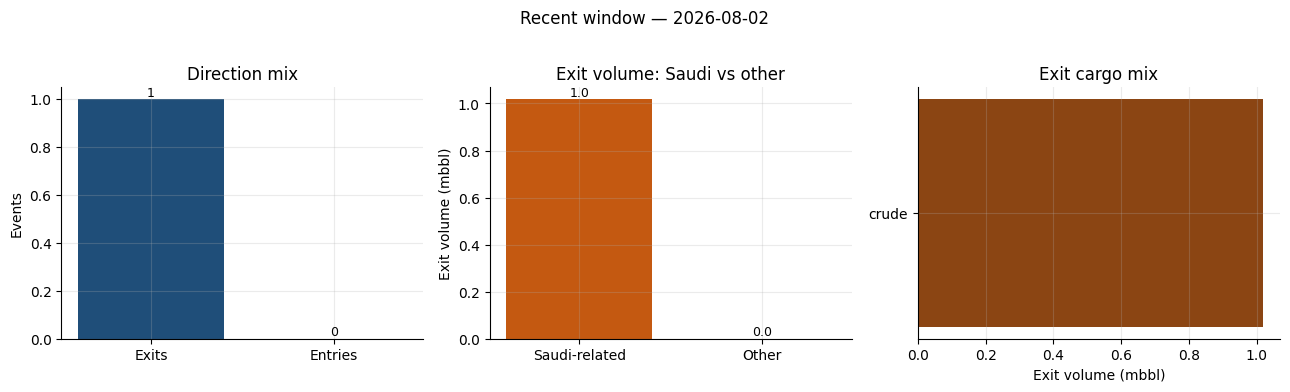

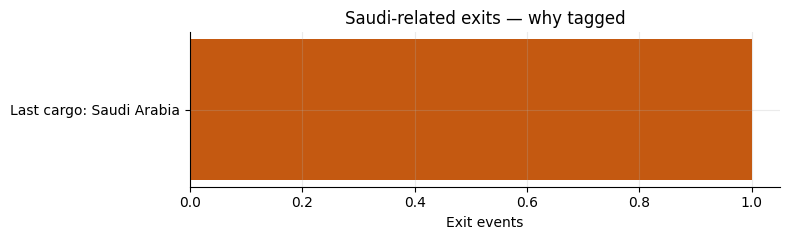

In [34]:
# --- Recent window viz ---
R_COLORS = {
    DIR_EXIT: "#1f4e79",
    DIR_ENTER: "#5b9bd5",
    "Saudi-related": "#c45911",
    "Other": "#548235",
    "crude": "#8b4513",
    "likely_crude": "#a97858",
    "products": "#2f5496",
    "ballast": "#7f7f7f",
    "unknown": "#b0b0b0",
    "other": "#7030a0",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# 1) Entries vs exits (events)
dir_counts = recent["Direction"].value_counts().reindex([DIR_EXIT, DIR_ENTER], fill_value=0)
axes[0].bar(
    ["Exits", "Entries"],
    dir_counts.values,
    color=[R_COLORS[DIR_EXIT], R_COLORS[DIR_ENTER]],
)
axes[0].set_ylabel("Events")
axes[0].set_title("Direction mix")
for i, v in enumerate(dir_counts.values):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)

# 2) Exit volume Saudi vs Other
vol_sa = (
    recent_ex.groupby("saudi_bucket")["volume_bbl"]
    .sum()
    .reindex(["Saudi-related", "Other"], fill_value=0.0)
    / 1e6
)
axes[1].bar(vol_sa.index, vol_sa.values, color=[R_COLORS["Saudi-related"], R_COLORS["Other"]])
axes[1].set_ylabel("Exit volume (mbbl)")
axes[1].set_title("Exit volume: Saudi vs other")
for i, v in enumerate(vol_sa.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

# 3) Exit cargo group
cg = recent_ex.groupby("cargo_group")["volume_bbl"].sum().sort_values(ascending=True) / 1e6
axes[2].barh(
    cg.index.astype(str),
    cg.values,
    color=[R_COLORS.get(c, "#666") for c in cg.index],
)
axes[2].set_xlabel("Exit volume (mbbl)")
axes[2].set_title("Exit cargo mix")

fig.suptitle(f"Recent window — {recent_label}", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Daily bars inside the window (useful on Mon Fri–Mon span)
if recent_start_day != recent_end_day:
    daily = (
        recent.assign(day=recent["Crossing Date"].dt.normalize())
        .groupby(["day", "Direction"])
        .size()
        .unstack(fill_value=0)
    )
    for col in [DIR_EXIT, DIR_ENTER]:
        if col not in daily.columns:
            daily[col] = 0

    fig, ax = plt.subplots(figsize=(8, 3.4))
    x = np.arange(len(daily))
    w = 0.35
    ax.bar(x - w / 2, daily[DIR_EXIT], w, label="Exits", color=R_COLORS[DIR_EXIT])
    ax.bar(x + w / 2, daily[DIR_ENTER], w, label="Entries", color=R_COLORS[DIR_ENTER])
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%a %d %b") for d in daily.index], rotation=30, ha="right")
    ax.set_ylabel("Events")
    ax.set_title(f"Daily crossings inside recent window — {recent_label}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Saudi reason breakdown (exits) if any
if len(sa_ex):
    reason_counts = sa_ex["saudi_reason"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.35 * len(reason_counts) + 1)))
    ax.barh(reason_counts.index.astype(str), reason_counts.values, color="#c45911")
    ax.set_xlabel("Exit events")
    ax.set_title("Saudi-related exits — why tagged")
    plt.tight_layout()
    plt.show()


In [35]:
recent

,Vessel Name,IMO,Vessel Classification,Flag Name,Direction,Crossing Date,Crossing Type,Loading State,Cargo Type,Quantity,Quantity Unit,Last Cargo Zone,Last Cargo Country,Next Port,Next Port Country,Deadweight,Build Year,Build Country,dwt_kdwt,afra_class,cargo_group,cargo_source,volume_bbl,sanctioned_iran,sanctioned_sdn,sanctioned_any,is_dark_fleet,fleet,saudi_flag,saudi_load,saudi_dest,saudi_related,saudi_layers,saudi_reason,saudi_bucket
0,LESVOS,9772321,Suezmax/LR3,MALTA,Exited Red Sea,2026-08-02,AIS Off,Laden,Crude/Co,1017760,bbl,Yanbu,Saudi Arabia,NaN,NaN,156949,"2,017",CHINA,156.949,LR2,crude,tagged,1017760.0,False,False,False,False,clean fleet,False,True,False,True,load,Last cargo: Saudi Arabia,Saudi-related


## 7. Overall flow pulse

Daily / weekly entries & exits — first check whether *total* traffic moved.

In [36]:
SHOW_COLS = [
    "Crossing Date",
    "Vessel Name",
    "IMO",
    "Flag Name",
    "Direction",
    "Loading State",
    "Cargo Type",
    "cargo_group",
    "Quantity",
    "volume_bbl",
    "Last Cargo Zone",
    "Last Cargo Country",
    "Next Port",
    "Next Port Country",
    "afra_class",
    "fleet",
    "saudi_bucket",
    "saudi_reason",
]

exited = period[period["Direction"] == DIR_EXIT].sort_values("Crossing Date")
entered = period[period["Direction"] == DIR_ENTER].sort_values("Crossing Date")

print(f"=== Exited Red Sea (period) — {len(exited):,} events / {exited['IMO'].nunique():,} vessels ===")
display(
    exited.groupby("Loading State")
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
)
print(f"\n=== Entered Red Sea (period) — {len(entered):,} events / {entered['IMO'].nunique():,} vessels ===")
display(
    entered.groupby("Loading State")
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
)

weekly = (
    period.assign(week=period["Crossing Date"].dt.to_period("W").dt.start_time)
    .groupby(["week", "Direction"])
    .agg(events=("IMO", "size"), volume_bbl=("volume_bbl", "sum"))
    .reset_index()
)
weekly_pivot = weekly.pivot_table(
    index="week", columns="Direction", values=["events", "volume_bbl"], fill_value=0
)
print("\n=== Weekly crossings (events + laden volume) ===")
display(weekly_pivot.tail(16))


=== Exited Red Sea (period) — 524 events / 383 vessels ===


,events,vessels,volume_bbl,volume_mbbl
Loading State,,,,
Ballast,18,18,0.0,0.000000
Laden,506,368,524443967.0,524.443967



=== Entered Red Sea (period) — 37 events / 37 vessels ===


,events,vessels,volume_bbl,volume_mbbl
Loading State,,,,
Ballast,5,5,0.0,0.000000
Laden,32,32,15782773.0,15.782773



=== Weekly crossings (events + laden volume) ===


events                     volume_bbl               
Direction  Entered Red Sea Exited Red Sea Entered Red Sea Exited Red Sea
week                                                                    
2026-04-13             0.0           22.0             0.0     22826487.0
2026-04-20             0.0           23.0             0.0     23704681.0
2026-04-27             0.0           21.0             0.0     29652001.0
2026-05-04             1.0           19.0        481277.0     24761874.0
2026-05-11             0.0           19.0             0.0     24990458.0
2026-05-18             0.0           21.0             0.0     25851181.0
2026-05-25             0.0           17.0             0.0     20674827.0
2026-06-01             0.0           25.0             0.0     25033872.0
2026-06-08             0.0           23.0             0.0     26390577.0
2026-06-15             0.0           25.0             0.0     29515888.0
2026-06-22             0.0           26.0             0.0     29594434.0
2026-06-29             0.0           25.0             0.0     29330119.0
2026-07-06             1.0           20.0        123695.0     22916266.0
2026-07-13             1.0           18.0             0.0     19610822.0
2026-07-20             0.0            9.0             0.0     14052329.0
2026-07-27             0.0            5.0             0.0      5799758.0

## 8. Pre / post `EVENT_DATE` — total vs Saudi-related

Core test: did overall flow drop, or mainly the Saudi-related slice?

In [37]:
def summarize_window(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Compact event / vessel / volume stats for a pre or post slice."""
    rows = []
    for bucket, sub in [
        ("All", df),
        ("Saudi-related", df[df["saudi_related"]]),
        ("Other", df[~df["saudi_related"]]),
    ]:
        ex = sub[sub["Direction"] == DIR_EXIT]
        en = sub[sub["Direction"] == DIR_ENTER]
        rows.append(
            {
                "window": label,
                "bucket": bucket,
                "events": len(sub),
                "vessels": sub["IMO"].nunique(),
                "exits": len(ex),
                "entries": len(en),
                "exit_volume_mbbl": ex["volume_bbl"].sum() / 1e6,
                "laden_exits": int((ex["Loading State"] == "Laden").sum()),
                "saudi_share_events": (
                    sub["saudi_related"].mean() if bucket == "All" and len(sub) else np.nan
                ),
                "saudi_share_exit_vol": (
                    ex.loc[ex["saudi_related"], "volume_bbl"].sum() / ex["volume_bbl"].sum()
                    if bucket == "All" and ex["volume_bbl"].sum() > 0
                    else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


cmp = pd.concat(
    [summarize_window(pre, f"PRE {pre_label}"), summarize_window(post, f"POST {post_label}")],
    ignore_index=True,
)
pre_col = [c for c in cmp["window"].unique() if c.startswith("PRE")][0]
post_col = [c for c in cmp["window"].unique() if c.startswith("POST")][0]

metrics = ["events", "exits", "entries", "exit_volume_mbbl", "laden_exits"]
delta_rows = []
for bucket in ["All", "Saudi-related", "Other"]:
    row = {"bucket": bucket}
    for m in metrics:
        a = cmp.loc[(cmp["bucket"] == bucket) & (cmp["window"] == pre_col), m].iloc[0]
        b = cmp.loc[(cmp["bucket"] == bucket) & (cmp["window"] == post_col), m].iloc[0]
        row[f"pre_{m}"] = a
        row[f"post_{m}"] = b
        row[f"pct_chg_{m}"] = (b / a - 1.0) if a else np.nan
    delta_rows.append(row)
delta = pd.DataFrame(delta_rows)

print(f"EVENT_DATE = {EVENT_DATE} | pre={pre_label} | post={post_label}")
print("\n=== Window summaries ===")
display(cmp.round(3))
print("\n=== Pre → post % change (negative = drop) ===")
display(delta.round(3))

print("\n=== Saudi-related EXIT events by reason (pre vs post) ===")
for label, df in [("PRE", pre), ("POST", post)]:
    ex_s = df[(df["Direction"] == DIR_EXIT) & df["saudi_related"]]
    print(f"\n{label} ({len(ex_s)} exits)")
    print(ex_s["saudi_reason"].value_counts())


EVENT_DATE = 2026-07-01 | pre=2026-06-03 → 2026-06-30 | post=2026-07-01 → 2026-07-28

=== Window summaries ===


,window,bucket,events,vessels,exits,entries,exit_volume_mbbl,laden_exits,saudi_share_events,saudi_share_exit_vol
0,PRE 2026-06-03 → 2026-06-30,All,94,93,94,0,108.702,91,1.0,1.0
1,PRE 2026-06-03 → 2026-06-30,Saudi-related,94,93,94,0,108.702,91,NaN,NaN
2,PRE 2026-06-03 → 2026-06-30,Other,0,0,0,0,0.000,0,NaN,NaN
3,POST 2026-07-01 → 2026-07-28,All,71,71,69,2,81.275,65,1.0,1.0
4,POST 2026-07-01 → 2026-07-28,Saudi-related,71,71,69,2,81.275,65,NaN,NaN
5,POST 2026-07-01 → 2026-07-28,Other,0,0,0,0,0.000,0,NaN,NaN



=== Pre → post % change (negative = drop) ===


,bucket,pre_events,post_events,pct_chg_events,pre_exits,post_exits,pct_chg_exits,pre_entries,post_entries,pct_chg_entries,pre_exit_volume_mbbl,post_exit_volume_mbbl,pct_chg_exit_volume_mbbl,pre_laden_exits,post_laden_exits,pct_chg_laden_exits
0,All,94,71,-0.245,94,69,-0.266,0,2,NaN,108.702,81.275,-0.252,91,65,-0.286
1,Saudi-related,94,71,-0.245,94,69,-0.266,0,2,NaN,108.702,81.275,-0.252,91,65,-0.286
2,Other,0,0,NaN,0,0,NaN,0,0,NaN,0.000,0.000,NaN,0,0,NaN



=== Saudi-related EXIT events by reason (pre vs post) ===

PRE (94 exits)
saudi_reason
Last cargo: Saudi Arabia               71
Saudi flag + last cargo SA             17
Last cargo SA + next port SA            4
Flag + last cargo SA + next port SA     2
Name: count, dtype: int64

POST (69 exits)
saudi_reason
Last cargo: Saudi Arabia        63
Last cargo SA + next port SA     3
Saudi flag + last cargo SA       3
Name: count, dtype: int64


## 9. Saudi share over time

If Saudi share of exits / exit volume falls while total holds up → Saudi-specific pressure.
If both fall together → broader corridor disruption.

In [38]:
ex_all = period[period["Direction"] == DIR_EXIT].copy()
ex_all["week"] = ex_all["Crossing Date"].dt.to_period("W").dt.start_time

vol_week = (
    ex_all.groupby(["week", "saudi_bucket"])["volume_bbl"].sum().unstack(fill_value=0.0) / 1e6
)
for col in ["Saudi-related", "Other"]:
    if col not in vol_week.columns:
        vol_week[col] = 0.0
vol_week["total"] = vol_week["Saudi-related"] + vol_week["Other"]
vol_week["saudi_share_vol"] = vol_week["Saudi-related"] / vol_week["total"].replace(0, np.nan)

evt_week = ex_all.groupby(["week", "saudi_bucket"]).size().unstack(fill_value=0)
for col in ["Saudi-related", "Other"]:
    if col not in evt_week.columns:
        evt_week[col] = 0
evt_week["total"] = evt_week["Saudi-related"] + evt_week["Other"]
evt_week["saudi_share_exits"] = evt_week["Saudi-related"] / evt_week["total"].replace(0, np.nan)

print("=== Weekly EXIT volume (mbbl) + Saudi share ===")
display(
    vol_week.join(
        evt_week[["Saudi-related", "Other", "saudi_share_exits"]], rsuffix="_evt"
    )
    .rename(columns={"Saudi-related_evt": "saudi_exits", "Other_evt": "other_exits"})
    .round(3)
    .tail(20)
)

# Layer breakdown over time (events; layers can overlap on one row)
layer_week = (
    ex_all.assign(
        flag=ex_all["saudi_flag"].astype(int),
        load=ex_all["saudi_load"].astype(int),
        dest=ex_all["saudi_dest"].astype(int),
    )
    .groupby("week")[["flag", "load", "dest"]]
    .sum()
)
print("\n=== Weekly EXIT events with each Saudi layer (can overlap) ===")
display(layer_week.tail(16))


=== Weekly EXIT volume (mbbl) + Saudi share ===


saudi_bucket,Saudi-related,Other,total,saudi_share_vol,saudi_exits,other_exits,saudi_share_exits
week,,,,,,,
2026-03-16,25.898,0.0,25.898,1.0,23,0,1.0
2026-03-23,22.263,0.0,22.263,1.0,23,0,1.0
2026-03-30,31.258,0.0,31.258,1.0,26,0,1.0
2026-04-06,21.288,0.0,21.288,1.0,20,0,1.0
2026-04-13,22.826,0.0,22.826,1.0,22,0,1.0
2026-04-20,23.705,0.0,23.705,1.0,23,0,1.0
2026-04-27,29.652,0.0,29.652,1.0,21,0,1.0
2026-05-04,24.762,0.0,24.762,1.0,19,0,1.0
2026-05-11,24.990,0.0,24.990,1.0,19,0,1.0



=== Weekly EXIT events with each Saudi layer (can overlap) ===


,flag,load,dest
week,,,
2026-04-13,1,22,0
2026-04-20,2,23,0
2026-04-27,1,21,0
2026-05-04,1,19,0
2026-05-11,2,19,1
2026-05-18,2,21,1
2026-05-25,2,17,1
2026-06-01,6,25,1
2026-06-08,4,23,0


## 10. Cargo mix — Saudi-related vs other

Check whether crude / products composition shifted differently for Saudi exposure.

In [39]:
def cargo_break(df: pd.DataFrame, label: str) -> pd.DataFrame:
    ex = df[df["Direction"] == DIR_EXIT]
    g = (
        ex.groupby(["saudi_bucket", "cargo_group"])
        .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
        .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
        .reset_index()
    )
    g.insert(0, "window", label)
    return g


cargo_cmp = pd.concat(
    [cargo_break(pre, "PRE"), cargo_break(post, "POST")],
    ignore_index=True,
)
print("=== Exit cargo_group by Saudi bucket (pre / post) ===")
display(
    cargo_cmp.pivot_table(
        index=["saudi_bucket", "cargo_group"],
        columns="window",
        values=["events", "volume_mbbl"],
        fill_value=0,
    ).round(2)
)

print("\n=== Tagged Cargo Type for Saudi-loaded exits (period) ===")
sa_load_ex = exited[exited["saudi_load"]]
display(sa_load_ex["Cargo Type"].value_counts(dropna=False).head(15))


=== Exit cargo_group by Saudi bucket (pre / post) ===


events       volume_mbbl       
window                      POST   PRE        POST    PRE
saudi_bucket  cargo_group                                
Saudi-related ballast        4.0   3.0        0.00   0.00
              crude         41.0  56.0       73.16  95.87
              products      24.0  34.0        8.11  12.83
              unknown        0.0   1.0        0.00   0.00


=== Tagged Cargo Type for Saudi-loaded exits (period) ===


Cargo Type
Crude/Co     249
CPP          166
Chemicals     70
NaN           20
DPP           13
Veg/Bio        6
Name: count, dtype: int64

## 11. Direction asymmetry & "likely still in Red Sea"

A rise in net entries (or uncleared entries) can signal vessels lingering / waiting, not just fewer crossings.

In [40]:
# Weekly net flow: entries - exits
flow_week = (
    period.assign(week=period["Crossing Date"].dt.to_period("W").dt.start_time)
    .groupby(["week", "Direction"])
    .size()
    .unstack(fill_value=0)
)
for col in [DIR_ENTER, DIR_EXIT]:
    if col not in flow_week.columns:
        flow_week[col] = 0
flow_week["net_enter"] = flow_week[DIR_ENTER] - flow_week[DIR_EXIT]
print("=== Weekly direction balance (positive net_enter = more entries than exits) ===")
display(flow_week.tail(16))

# Likely still inside Red Sea: last event as of AS_OF is an entry.
hist_to_asof = crossings[crossings["Crossing Date"] <= as_of_ts].copy()
last_evt = (
    hist_to_asof.sort_values(["IMO", "Crossing Date"]).groupby("IMO", as_index=False).tail(1)
)
likely_inside = last_evt[last_evt["Direction"] == DIR_ENTER].copy()
likely_inside_period = likely_inside[likely_inside["Crossing Date"] >= start_ts].sort_values(
    "Crossing Date"
)

print(
    f"\nLikely still in Red Sea as of {as_of}: "
    f"{len(likely_inside):,} vessels (last event = Entered Red Sea)"
)
print(
    f"  of which entered on/after {START_DATE}: {len(likely_inside_period):,} | "
    f"Saudi-related: {likely_inside_period['saudi_related'].sum():,}"
)
display(
    likely_inside_period.groupby("saudi_bucket")
    .agg(vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
)
print("\nRecent likely-inside sample:")
display(likely_inside_period[SHOW_COLS].tail(12))


=== Weekly direction balance (positive net_enter = more entries than exits) ===


Direction,Entered Red Sea,Exited Red Sea,net_enter
week,,,
2026-04-13,0,22,-22
2026-04-20,0,23,-23
2026-04-27,0,21,-21
2026-05-04,1,19,-18
2026-05-11,0,19,-19
2026-05-18,0,21,-21
2026-05-25,0,17,-17
2026-06-01,0,25,-25
2026-06-08,0,23,-23



Likely still in Red Sea as of 2026-08-02: 22 vessels (last event = Entered Red Sea)
  of which entered on/after 2026-01-01: 22 | Saudi-related: 22


,vessels,volume_bbl,volume_mbbl
saudi_bucket,,,
Saudi-related,22,11270635.0,11.270635



Recent likely-inside sample:


,Crossing Date,Vessel Name,IMO,Flag Name,Direction,Loading State,Cargo Type,cargo_group,Quantity,volume_bbl,Last Cargo Zone,Last Cargo Country,Next Port,Next Port Country,afra_class,fleet,saudi_bucket,saudi_reason
477,2026-02-14,ALTESSE,9440473,MARSHALL ISLANDS,Entered Red Sea,Laden,CPP,products,148666,148666.0,Jubail Industrial Port,Saudi Arabia,Yanbu,Saudi Arabia,LR1,clean fleet,Saudi-related,Last cargo SA + next port SA
470,2026-02-18,PRABHU MIHIKAA,9674775,SINGAPORE,Entered Red Sea,Laden,"Chemicals, Methanol",products,115632,115632.0,Jubail Industrial Port,Saudi Arabia,Rabigh,Saudi Arabia,MR,clean fleet,Saudi-related,Last cargo SA + next port SA
468,2026-02-19,KHURAIS,9783679,SAUDI ARABIA,Entered Red Sea,Laden,Crude/Co,crude,2000002,2000002.0,Ras Tanura,Saudi Arabia,Ain Sukhna,Egypt,VLCC,clean fleet,Saudi-related,Saudi flag + last cargo SA
467,2026-02-20,ENCELIA,9240172,SAUDI ARABIA,Entered Red Sea,Laden,Crude/Co,crude,699999,699999.0,Ras Tanura,Saudi Arabia,Shuqaiq,Saudi Arabia,AFRA,clean fleet,Saudi-related,Flag + last cargo SA + next port SA
465,2026-02-22,XT EXPLORATION,1043023,MALTA,Entered Red Sea,Laden,Methanol,products,83982,83982.0,Jubail Industrial Port,Saudi Arabia,Yanbu,Saudi Arabia,GP,clean fleet,Saudi-related,Last cargo SA + next port SA
464,2026-02-22,LOULOULIGHT,9594901,MARSHALL ISLANDS,Entered Red Sea,Laden,CPP,products,511940,511940.0,Ras Tanura,Saudi Arabia,Isle of Grain,United Kingdom,LR1,clean fleet,Saudi-related,Last cargo: Saudi Arabia
451,2026-02-27,IXORA,9940459,LIBERIA,Entered Red Sea,Laden,DPP,products,527023,527023.0,Ras Tanura,Saudi Arabia,Houston,United States,AFRA,clean fleet,Saudi-related,Last cargo: Saudi Arabia
450,2026-02-28,NEW DISCOVERY,9269075,LIBERIA,Entered Red Sea,Laden,Crude/Co,crude,1040404,1040404.0,Ras Tanura,Saudi Arabia,Aqaba,Jordan,LR2,clean fleet,Saudi-related,Last cargo: Saudi Arabia
436,2026-03-05,NAFEES,9830800,SAUDI ARABIA,Entered Red Sea,Laden,Crude/Co,crude,2128660,2128660.0,Ras Tanura,Saudi Arabia,Ain Sukhna,Egypt,ULCC,clean fleet,Saudi-related,Saudi flag + last cargo SA
435,2026-03-05,GOLDEN SAPLING,9185841,HONG KONG,Entered Red Sea,Laden,Chemicals,products,132690,132690.0,Jubail Industrial Port,Saudi Arabia,Adabiya,Egypt,GP,clean fleet,Saudi-related,Last cargo: Saudi Arabia


## 12. Saudi Red Sea load zones

Yanbu / Rabigh / Jizan dominate Saudi-loaded crossings — useful if targeting is port-proximate.

In [41]:
sa_zones = (
    period[period["saudi_load"]]
    .assign(week=lambda d: d["Crossing Date"].dt.to_period("W").dt.start_time)
    .groupby(["week", "Last Cargo Zone"])
    .agg(events=("IMO", "size"), volume_mbbl=("volume_bbl", lambda s: s.sum() / 1e6))
    .reset_index()
)
zone_totals = (
    period[period["saudi_load"]]
    .groupby("Last Cargo Zone")
    .agg(events=("IMO", "size"), volume_mbbl=("volume_bbl", lambda s: s.sum() / 1e6))
    .sort_values("volume_mbbl", ascending=False)
)
print("=== Saudi last-cargo zones (period totals) ===")
display(zone_totals.head(12))

top_zones = zone_totals.head(5).index.tolist()
zone_week = (
    sa_zones[sa_zones["Last Cargo Zone"].isin(top_zones)]
    .pivot_table(index="week", columns="Last Cargo Zone", values="volume_mbbl", fill_value=0)
)
print("\n=== Weekly volume (mbbl) for top Saudi load zones ===")
display(zone_week.tail(16).round(2))


=== Saudi last-cargo zones (period totals) ===


,events,volume_mbbl
Last Cargo Zone,,
Yanbu,379,479.312943
Rabigh,77,23.556765
Jizan,49,19.234814
Ras Tanura,9,8.147983
Jubail Industrial Port,21,6.715057
Yanbu Light.,2,1.310281
Jeddah,14,1.270283
Yanbu Commercial,6,0.678614
Jeddah South,1,0.000000



=== Weekly volume (mbbl) for top Saudi load zones ===


Last Cargo Zone,Jizan,Jubail Industrial Port,Rabigh,Ras Tanura,Yanbu
week,,,,,
2026-04-13,0.49,0.00,1.30,0.0,20.95
2026-04-20,0.47,0.00,1.67,0.0,21.57
2026-04-27,0.00,0.00,0.69,0.0,28.96
2026-05-04,0.35,0.00,0.99,0.0,23.84
2026-05-11,0.30,0.00,0.98,0.0,23.71
2026-05-18,0.35,0.00,0.28,0.0,25.09
2026-05-25,0.00,0.00,0.68,0.0,20.00
2026-06-01,0.24,0.00,1.38,0.0,23.28
2026-06-08,0.00,0.00,0.32,0.0,26.08


## 13. Dark fleet vs clean fleet (OFAC)

Sanctioned hulls may behave differently under Red Sea risk — useful contrast to Saudi exposure.

In [42]:
print("=== Period events by fleet × direction ===")
display(
    period.groupby(["fleet", "Direction"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
    .reset_index()
)

print("\n=== Exit volume by fleet × Saudi bucket (period) ===")
display(
    exited.groupby(["fleet", "saudi_bucket"])
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
    .reset_index()
)

print("\n=== Pre → post exit volume (mbbl) by fleet ===")
fleet_cmp = []
for label, df in [("PRE", pre), ("POST", post)]:
    ex = df[df["Direction"] == DIR_EXIT]
    g = ex.groupby("fleet")["volume_bbl"].sum() / 1e6
    fleet_cmp.append(g.rename(label))
display(pd.concat(fleet_cmp, axis=1).fillna(0).round(2))


=== Period events by fleet × direction ===


,fleet,Direction,events,vessels,volume_bbl,volume_mbbl
0,clean fleet,Entered Red Sea,37,37,15782773.0,15.782773
1,clean fleet,Exited Red Sea,524,383,524443967.0,524.443967



=== Exit volume by fleet × Saudi bucket (period) ===


,fleet,saudi_bucket,events,vessels,volume_bbl,volume_mbbl
0,clean fleet,Saudi-related,524,383,524443967.0,524.443967



=== Pre → post exit volume (mbbl) by fleet ===


,PRE,POST
fleet,,
clean fleet,108.7,81.27


## 14. AFRA class mix


In [43]:
print("=== Exits by AFRA class (period) ===")
afra_exits = (
    exited.groupby("afra_class")
    .agg(events=("IMO", "size"), vessels=("IMO", "nunique"), volume_bbl=("volume_bbl", "sum"))
    .assign(volume_mbbl=lambda d: d["volume_bbl"] / 1e6)
    .sort_values("volume_bbl", ascending=False)
)
display(afra_exits)

print("\n=== Pre → post exit volume (mbbl) by AFRA × Saudi bucket ===")
afra_cmp = []
for label, df in [("PRE", pre), ("POST", post)]:
    ex = df[df["Direction"] == DIR_EXIT]
    g = (
        ex.groupby(["afra_class", "saudi_bucket"])["volume_bbl"]
        .sum()
        .div(1e6)
        .rename(label)
    )
    afra_cmp.append(g)
display(pd.concat(afra_cmp, axis=1).fillna(0).round(2).sort_values("PRE", ascending=False).head(24))


=== Exits by AFRA class (period) ===


,events,vessels,volume_bbl,volume_mbbl
afra_class,,,,
VLCC,172,126,348527926.0,348.527926
LR1,160,113,54727518.0,54.727518
ULCC,22,17,44832188.0,44.832188
AFRA,63,49,37843918.0,37.843918
LR2,28,23,28301691.0,28.301691
GP,50,32,5267571.0,5.267571
MR,27,21,4943155.0,4.943155
Below GP,2,2,0.0,0.000000



=== Pre → post exit volume (mbbl) by AFRA × Saudi bucket ===


,,PRE,POST
afra_class,saudi_bucket,,
VLCC,Saudi-related,70.36,66.56
ULCC,Saudi-related,14.35,2.16
AFRA,Saudi-related,9.93,6.26
LR2,Saudi-related,6.34,1.04
LR1,Saudi-related,6.16,4.08
MR,Saudi-related,1.06,0.63
GP,Saudi-related,0.51,0.55


## 15. Frequent BeM crossers


In [44]:
freq = (
    period.groupby("IMO", as_index=False)
    .agg(
        vessel_name=("Vessel Name", "last"),
        flag=("Flag Name", "last"),
        crossings=("Crossing Date", "size"),
        exits=("Direction", lambda s: (s == DIR_EXIT).sum()),
        entries=("Direction", lambda s: (s == DIR_ENTER).sum()),
        first_seen=("Crossing Date", "min"),
        last_seen=("Crossing Date", "max"),
        saudi_related=("saudi_related", "max"),
        saudi_reason=(
            "saudi_reason",
            lambda s: ", ".join(sorted({x for x in s if x != "not Saudi-related"}))
            or "not Saudi-related",
        ),
        fleet=("fleet", "last"),
        afra_class=("afra_class", "last"),
    )
)
vol_out = (
    exited.groupby("IMO", as_index=False)["volume_bbl"]
    .sum()
    .rename(columns={"volume_bbl": "volume_out_bbl"})
)
freq = freq.merge(vol_out, on="IMO", how="left")
freq["volume_out_bbl"] = freq["volume_out_bbl"].fillna(0.0)
freq = freq[freq["crossings"] >= MIN_CROSSINGS].sort_values(
    ["crossings", "volume_out_bbl"], ascending=[False, False]
)

print(f"Vessels with ≥{MIN_CROSSINGS} crossings in period: {len(freq):,}")
print(f"  Saudi-related (any event): {freq['saudi_related'].sum():,}")
display(freq.head(25))


Vessels with ≥2 crossings in period: 125
  Saudi-related (any event): 125


,IMO,vessel_name,flag,crossings,exits,entries,first_seen,last_seen,saudi_related,saudi_reason,fleet,afra_class,volume_out_bbl
374,9913511,LAHORE,PAKISTAN,5,5,0,2026-03-14,2026-07-26,True,Last cargo: Saudi Arabia,clean fleet,AFRA,2777102.0
73,9327140,SEA FORTUNE,HONG KONG,5,4,1,2026-01-03,2026-07-13,True,Last cargo: Saudi Arabia,clean fleet,GP,536544.0
118,9386964,DORRA,SAUDI ARABIA,4,4,0,2026-01-02,2026-06-18,True,Saudi flag + last cargo SA,clean fleet,VLCC,8345319.0
368,9903413,KARACHI,PAKISTAN,4,4,0,2026-04-19,2026-07-28,True,Last cargo: Saudi Arabia,clean fleet,AFRA,2184671.0
95,9362372,BLOSSOM GLORY,HONG KONG,4,4,0,2026-04-24,2026-06-20,True,Last cargo: Saudi Arabia,clean fleet,LR1,1287889.0
203,9459008,NCC NASMA,SAUDI ARABIA,4,3,1,2026-01-11,2026-06-27,True,"Flag + last cargo SA + next port SA, Saudi flag + last cargo SA",clean fleet,LR1,947754.0
205,9459022,NCC NAJEM,SAUDI ARABIA,4,3,1,2026-02-02,2026-05-12,True,"Flag + last cargo SA + next port SA, Saudi flag + last cargo SA",clean fleet,LR1,928898.0
172,9424209,ORIENTAL ARK,LIBERIA,3,3,0,2026-04-12,2026-07-10,True,Last cargo: Saudi Arabia,clean fleet,ULCC,6467610.0
136,9398058,NEW PROSPECT,LIBERIA,3,3,0,2026-04-03,2026-06-27,True,Last cargo: Saudi Arabia,clean fleet,VLCC,6322467.0
245,9560766,KALAMOS,LIBERIA,3,3,0,2026-04-01,2026-06-10,True,Last cargo: Saudi Arabia,clean fleet,VLCC,6083159.0


## 16. Visualizations


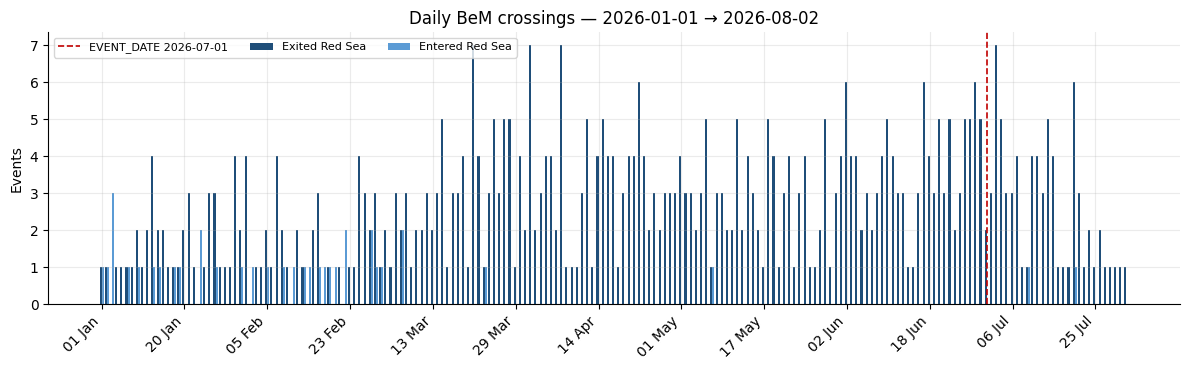

In [45]:
# Shared colors — one meaning per series across charts.
COLORS = {
    DIR_EXIT: "#1f4e79",
    DIR_ENTER: "#5b9bd5",
    "Saudi-related": "#c45911",
    "Other": "#548235",
    "crude": "#8b4513",
    "likely_crude": "#a97858",
    "products": "#2f5496",
    "ballast": "#7f7f7f",
    "unknown": "#b0b0b0",
    "other": "#7030a0",
    "dark fleet": "#595959",
    "clean fleet": "#2e75b6",
    "flag": "#c45911",
    "load": "#ed7d31",
    "dest": "#f4b183",
}

# --- 1) Daily pulse: entries vs exits ---
daily_counts = (
    period.assign(day=period["Crossing Date"].dt.normalize())
    .groupby(["day", "Direction"])
    .size()
    .unstack(fill_value=0)
)
for col in [DIR_EXIT, DIR_ENTER]:
    if col not in daily_counts.columns:
        daily_counts[col] = 0

fig, ax = plt.subplots(figsize=(12, 3.8))
x = np.arange(len(daily_counts))
width = 0.4
ax.bar(x - width / 2, daily_counts[DIR_EXIT], width, label=DIR_EXIT, color=COLORS[DIR_EXIT])
ax.bar(x + width / 2, daily_counts[DIR_ENTER], width, label=DIR_ENTER, color=COLORS[DIR_ENTER])
if start_ts <= event_ts <= end_ts and len(daily_counts):
    idx = int(np.argmin(np.abs((daily_counts.index - event_ts).asi8)))
    ax.axvline(idx, color="#c00000", ls="--", lw=1.2, label=f"EVENT_DATE {EVENT_DATE}")
step = max(1, len(daily_counts) // 12)
ax.set_xticks(x[::step])
ax.set_xticklabels(
    [d.strftime("%d %b") for d in daily_counts.index[::step]], rotation=45, ha="right"
)
ax.set_ylabel("Events")
ax.set_title(f"Daily BeM crossings — {period_label}")
ax.legend(loc="upper left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


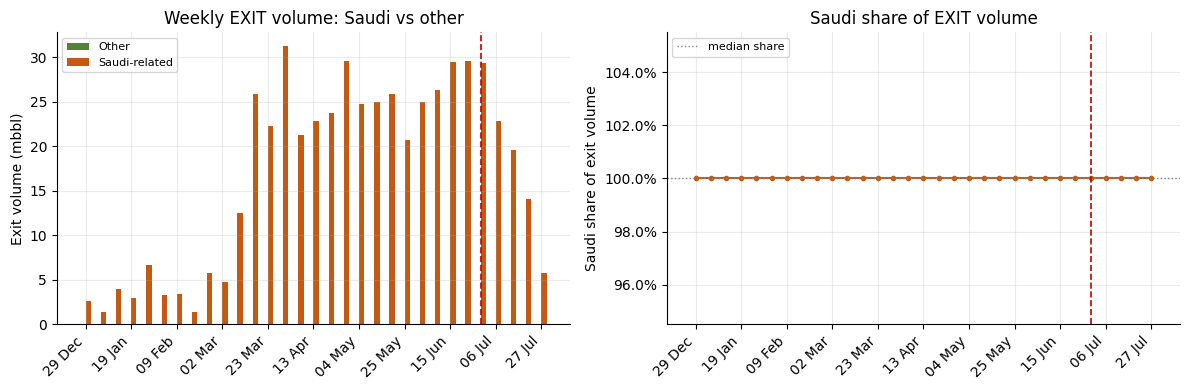

In [46]:
# --- 2) Weekly exit volume: Saudi-related vs Other ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

x = np.arange(len(vol_week))
width = 0.35
axes[0].bar(x - width / 2, vol_week["Other"], width, label="Other", color=COLORS["Other"])
axes[0].bar(
    x + width / 2,
    vol_week["Saudi-related"],
    width,
    label="Saudi-related",
    color=COLORS["Saudi-related"],
)
axes[0].set_ylabel("Exit volume (mbbl)")
axes[0].set_title("Weekly EXIT volume: Saudi vs other")
axes[0].legend(fontsize=8)

axes[1].plot(x, vol_week["saudi_share_vol"], color=COLORS["Saudi-related"], marker="o", ms=3)
axes[1].axhline(
    vol_week["saudi_share_vol"].median(), color="#888", ls=":", lw=1, label="median share"
)
axes[1].set_ylabel("Saudi share of exit volume")
axes[1].set_title("Saudi share of EXIT volume")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(fontsize=8)

if len(vol_week):
    evt_week_start = pd.Timestamp(EVENT_DATE).to_period("W").start_time
    if evt_week_start in vol_week.index:
        ei = list(vol_week.index).index(evt_week_start)
        for ax in axes:
            ax.axvline(ei, color="#c00000", ls="--", lw=1.2)

step = max(1, len(vol_week) // 10)
for ax in axes:
    ax.set_xticks(x[::step])
    ax.set_xticklabels(
        [d.strftime("%d %b") for d in vol_week.index[::step]], rotation=45, ha="right"
    )

plt.tight_layout()
plt.show()


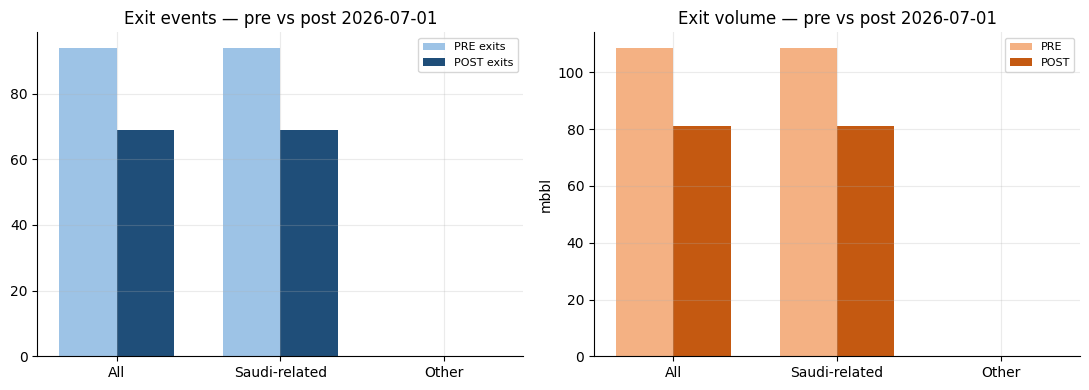

Pre → post % change in exit volume:
  All               -25.2%
  Saudi-related     -25.2%
  Other: n/a


In [47]:
# --- 3) Pre/post comparison bars ---
plot_delta = delta.set_index("bucket").loc[["All", "Saudi-related", "Other"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.arange(len(plot_delta))
width = 0.35
axes[0].bar(x - width / 2, plot_delta["pre_exits"], width, label="PRE exits", color="#9dc3e6")
axes[0].bar(x + width / 2, plot_delta["post_exits"], width, label="POST exits", color="#1f4e79")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_delta.index)
axes[0].set_title(f"Exit events — pre vs post {EVENT_DATE}")
axes[0].legend(fontsize=8)

axes[1].bar(
    x - width / 2, plot_delta["pre_exit_volume_mbbl"], width, label="PRE", color="#f4b183"
)
axes[1].bar(
    x + width / 2, plot_delta["post_exit_volume_mbbl"], width, label="POST", color="#c45911"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_delta.index)
axes[1].set_ylabel("mbbl")
axes[1].set_title(f"Exit volume — pre vs post {EVENT_DATE}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Pre → post % change in exit volume:")
for _, r in plot_delta.reset_index().iterrows():
    pct = r["pct_chg_exit_volume_mbbl"]
    if pd.notna(pct):
        print(f"  {r['bucket']:16s}  {pct:+.1%}")
    else:
        print(f"  {r['bucket']}: n/a")


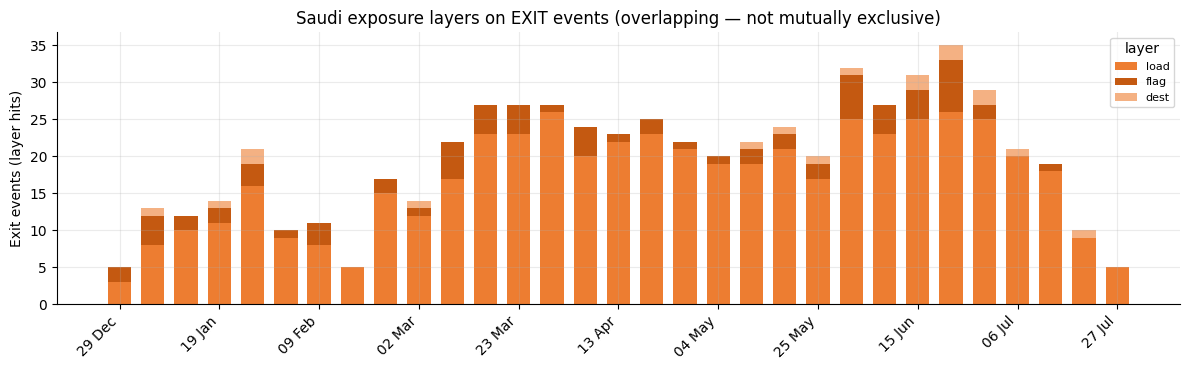

In [48]:
# --- 4) Saudi layer stacks (weekly exit events) ---
fig, ax = plt.subplots(figsize=(12, 3.8))
x = np.arange(len(layer_week))
bottom = np.zeros(len(layer_week))
for col in ["load", "flag", "dest"]:
    ax.bar(x, layer_week[col], bottom=bottom, label=col, color=COLORS[col], width=0.7)
    bottom = bottom + layer_week[col].to_numpy()
step = max(1, len(layer_week) // 10)
ax.set_xticks(x[::step])
ax.set_xticklabels(
    [d.strftime("%d %b") for d in layer_week.index[::step]], rotation=45, ha="right"
)
ax.set_ylabel("Exit events (layer hits)")
ax.set_title("Saudi exposure layers on EXIT events (overlapping — not mutually exclusive)")
ax.legend(title="layer", fontsize=8)
plt.tight_layout()
plt.show()


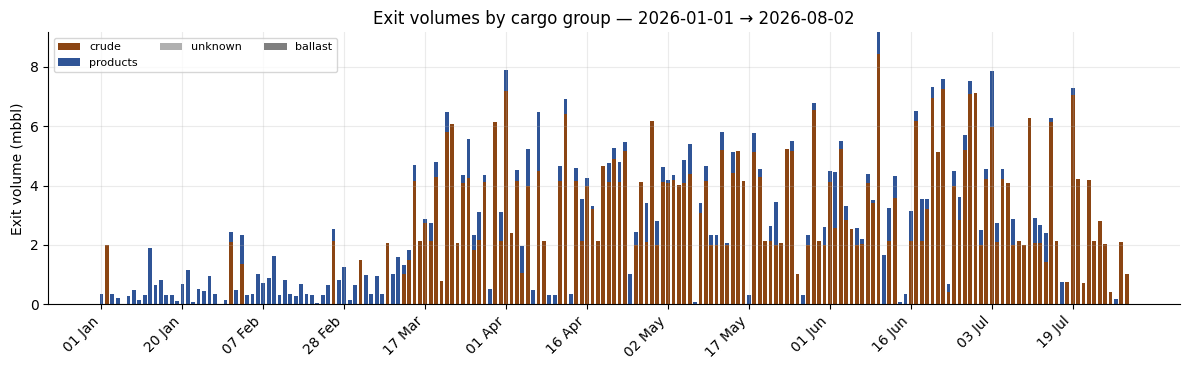

In [49]:
# --- 5) Exit volumes by cargo group over time ---
vol_daily = (
    exited.assign(day=exited["Crossing Date"].dt.normalize())
    .groupby(["day", "cargo_group"])["volume_bbl"]
    .sum()
    .unstack(fill_value=0.0)
    / 1e6
)
cargo_order = [
    c
    for c in ["crude", "likely_crude", "products", "other", "unknown", "ballast"]
    if c in vol_daily.columns
]
vol_daily = vol_daily[cargo_order]

fig, ax = plt.subplots(figsize=(12, 3.8))
bottom = np.zeros(len(vol_daily))
x = np.arange(len(vol_daily))
for col in vol_daily.columns:
    ax.bar(x, vol_daily[col], bottom=bottom, label=col, color=COLORS.get(col, "#666"), width=0.7)
    bottom = bottom + vol_daily[col].to_numpy()
step = max(1, len(vol_daily) // 12)
ax.set_xticks(x[::step])
ax.set_xticklabels(
    [d.strftime("%d %b") for d in vol_daily.index[::step]], rotation=45, ha="right"
)
ax.set_ylabel("Exit volume (mbbl)")
ax.set_title(f"Exit volumes by cargo group — {period_label}")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


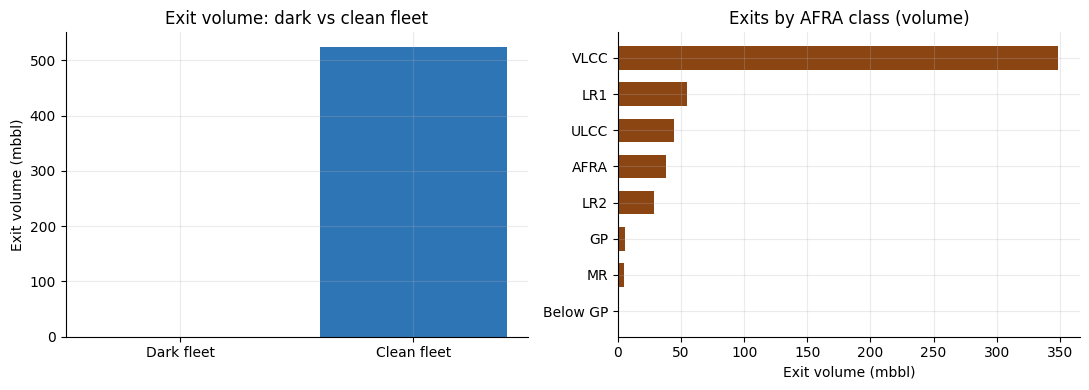

In [50]:
# --- 6) Dark vs clean + AFRA ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fleet_vol = (
    exited.groupby("fleet")["volume_bbl"].sum().reindex(["dark fleet", "clean fleet"], fill_value=0)
    / 1e6
)
axes[0].bar(
    ["Dark fleet", "Clean fleet"],
    fleet_vol.values,
    color=[COLORS["dark fleet"], COLORS["clean fleet"]],
)
axes[0].set_ylabel("Exit volume (mbbl)")
axes[0].set_title("Exit volume: dark vs clean fleet")

afra_plot = afra_exits.sort_values("volume_mbbl", ascending=True)
axes[1].barh(afra_plot.index.astype(str), afra_plot["volume_mbbl"], color="#8b4513", height=0.65)
axes[1].set_xlabel("Exit volume (mbbl)")
axes[1].set_title("Exits by AFRA class (volume)")

plt.tight_layout()
plt.show()


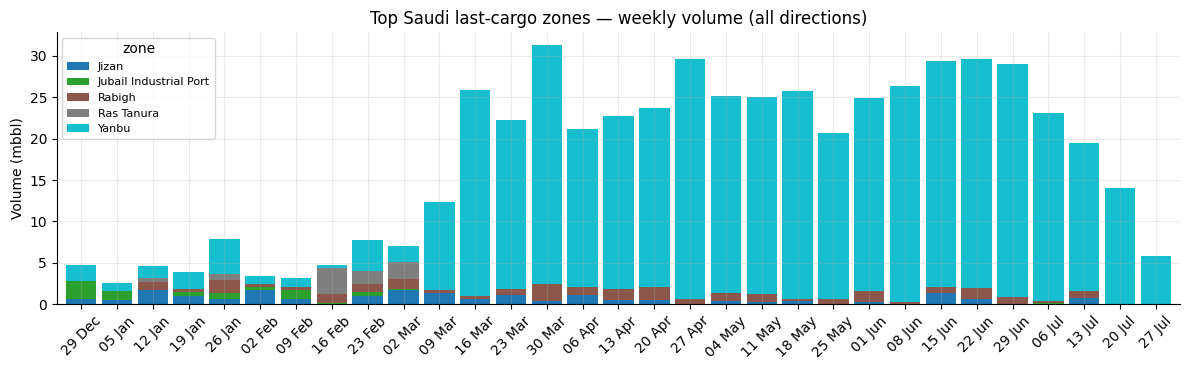

In [51]:
# --- 7) Top Saudi load zones over time (stacked weekly volume) ---
if len(zone_week):
    fig, ax = plt.subplots(figsize=(12, 3.8))
    # Avoid pandas Period/DatetimeIndex bar converter quirks — plot on a plain RangeIndex.
    zw = zone_week.copy()
    zw.index = [d.strftime("%d %b") for d in zone_week.index]
    zw.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab10")
    ax.set_ylabel("Volume (mbbl)")
    ax.set_title("Top Saudi last-cargo zones — weekly volume (all directions)")
    ax.legend(title="zone", fontsize=8, loc="upper left")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


## 17. Insight summary

Auto-computed from the pre/post windows. Re-run after changing `EVENT_DATE`.

In [52]:
def pct(x):
    return f"{x:+.1%}" if pd.notna(x) else "n/a"


all_row = delta.set_index("bucket").loc["All"]
sa_row = delta.set_index("bucket").loc["Saudi-related"]
ot_row = delta.set_index("bucket").loc["Other"]

pre_share = cmp.loc[
    (cmp["bucket"] == "All") & (cmp["window"] == pre_col), "saudi_share_exit_vol"
].iloc[0]
post_share = cmp.loc[
    (cmp["bucket"] == "All") & (cmp["window"] == post_col), "saudi_share_exit_vol"
].iloc[0]

sa_drop = sa_row["pct_chg_exit_volume_mbbl"]
ot_drop = ot_row["pct_chg_exit_volume_mbbl"]
all_drop = all_row["pct_chg_exit_volume_mbbl"]

if pd.notna(sa_drop) and pd.notna(ot_drop):
    if sa_drop < -0.15 and (pd.isna(ot_drop) or ot_drop > sa_drop + 0.10):
        verdict = (
            "MORE SAUDI-SPECIFIC — Saudi-related exit volume fell harder than other traffic."
        )
    elif pd.notna(all_drop) and all_drop < -0.15 and abs(sa_drop - ot_drop) < 0.10:
        verdict = (
            "BROADER DISRUPTION — Saudi and non-Saudi exit volumes moved similarly lower."
        )
    elif sa_drop >= -0.05 and ot_drop >= -0.05:
        verdict = (
            "NO CLEAR VOLUME DISRUPTION yet in this pre/post window "
            "(check EVENT_DATE / window length)."
        )
    else:
        verdict = "MIXED — inspect weekly share charts; signal depends on window choice."
else:
    verdict = "Insufficient data in pre/post windows."

print("=" * 72)
print("BeM / Red Sea — disruption read")
print("=" * 72)
print(f"EVENT_DATE:     {EVENT_DATE}")
print(f"PRE window:     {pre_label}  ({len(pre):,} events)")
print(f"POST window:    {post_label} ({len(post):,} events)")
print()
print("Exit volume change (pre → post):")
print(
    f"  All:            {pct(all_row['pct_chg_exit_volume_mbbl'])}   "
    f"({all_row['pre_exit_volume_mbbl']:.1f} → {all_row['post_exit_volume_mbbl']:.1f} mbbl)"
)
print(
    f"  Saudi-related:  {pct(sa_row['pct_chg_exit_volume_mbbl'])}   "
    f"({sa_row['pre_exit_volume_mbbl']:.1f} → {sa_row['post_exit_volume_mbbl']:.1f} mbbl)"
)
print(
    f"  Other:          {pct(ot_row['pct_chg_exit_volume_mbbl'])}   "
    f"({ot_row['pre_exit_volume_mbbl']:.1f} → {ot_row['post_exit_volume_mbbl']:.1f} mbbl)"
)
print()
print(f"Saudi share of exit volume: {pre_share:.1%} (pre) → {post_share:.1%} (post)")
print()
print("Saudi-related definition: flag OR last cargo country SA OR next port country SA.")
print(
    "  (Owner not in file — narrative targeting of Saudi-owned vessels "
    "cannot be measured directly.)"
)
print()
print("Layer mix among Saudi-related exits in POST:")
post_sa_ex = post[(post["Direction"] == DIR_EXIT) & post["saudi_related"]]
if len(post_sa_ex):
    for reason, cnt in post_sa_ex["saudi_reason"].value_counts().items():
        print(f"  {reason}: {cnt}")
else:
    print("  (none)")
print()
print(
    f"Likely still in Red Sea as of {as_of}: {len(likely_inside_period):,} "
    f"(Saudi-related {int(likely_inside_period['saudi_related'].sum())})"
)
print()
print("VERDICT:", verdict)
print("=" * 72)
print()
print("Tips: shorten/widen PRE_DAYS/POST_DAYS, or move EVENT_DATE, then re-run all cells.")


BeM / Red Sea — disruption read
EVENT_DATE:     2026-07-01
PRE window:     2026-06-03 → 2026-06-30  (94 events)
POST window:    2026-07-01 → 2026-07-28 (71 events)

Exit volume change (pre → post):
  All:            -25.2%   (108.7 → 81.3 mbbl)
  Saudi-related:  -25.2%   (108.7 → 81.3 mbbl)
  Other:          n/a   (0.0 → 0.0 mbbl)

Saudi share of exit volume: 100.0% (pre) → 100.0% (post)

Saudi-related definition: flag OR last cargo country SA OR next port country SA.
  (Owner not in file — narrative targeting of Saudi-owned vessels cannot be measured directly.)

Layer mix among Saudi-related exits in POST:
  Last cargo: Saudi Arabia: 63
  Last cargo SA + next port SA: 3
  Saudi flag + last cargo SA: 3

Likely still in Red Sea as of 2026-08-02: 22 (Saudi-related 22)

VERDICT: Insufficient data in pre/post windows.

Tips: shorten/widen PRE_DAYS/POST_DAYS, or move EVENT_DATE, then re-run all cells.
